<a href="https://colab.research.google.com/github/Zetastico/Inteligencia-Artificial-I/blob/main/Pr%C3%A1ctico_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practico 01
# Clasificación Binaria
###Pedro Jhoel Antonio Magne Ordoñez
###Ciencias de la Computación



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [12]:
# Cargar datos
# Usamos pandas para cargar porque tu dataset tiene encabezados y texto
df = pd.read_csv('/content/drive/MyDrive/IA Dataset/Practico 1/student_performance_prediction_dataset-2.csv')

# Reemplazo directo en la columna
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])
df['family_income'] = encoder.fit_transform(df['family_income'])
df['internet_access'] = encoder.fit_transform(df['internet_access'])
df['school_type'] = encoder.fit_transform(df['school_type'])
df['pass_fail'] = encoder.fit_transform(df['pass_fail'])


#df['family_income'] = df['family_income'].replace(['Low', 'Medium', 'High'], [0, 1, 2])
#df['internet_access'] = df['internet_access'].replace(['No', 'Yes'], [0, 1])
#df['school_type'] = df['school_type'].replace(['Public', 'Private'], [0, 1])
#df['pass_fail'] = df['pass_fail'].replace(['Fail', 'Pass'], [0, 1])

X = df.drop(columns=['pass_fail']).values
y = df['pass_fail'].values

m = y.size           # Número de ejemplos (m >= 50,000)
n = X.shape[1]       # Número de propiedades (n >= 40)
num_labels = 2       # Tus clases: 0 (Poor), 1 (Standard), 2 (Good)

print(m,n)
print(X)
print(y)

0         1
1         1
2         0
3         0
4         1
         ..
299995    0
299996    0
299997    1
299998    0
299999    1
Name: gender, Length: 300000, dtype: int64
300000 19
[[21.          1.          1.64540363 ...  1.          0.
  59.24874862]
 [18.          1.          4.46212555 ...  1.          1.
  58.59559517]
 [19.          0.          6.22021189 ...  1.          0.
  85.85528944]
 ...
 [16.          1.          3.27036067 ...  1.          1.
  30.199483  ]
 [17.          0.          1.90711565 ...  1.          1.
  65.07546563]
 [20.          1.          0.49870109 ...  0.          0.
  31.73352823]]
[1 1 1 ... 0 1 0]


In [42]:
print(X[2:])

[[ 1.         19.          0.         ...  1.          0.
  85.85528944]
 [ 1.         21.          0.         ...  1.          1.
  42.11750266]
 [ 1.         17.          1.         ...  1.          0.
  62.87047411]
 ...
 [ 1.         16.          1.         ...  1.          1.
  30.199483  ]
 [ 1.         17.          0.         ...  1.          1.
  65.07546563]
 [ 1.         20.          1.         ...  0.          0.
  31.73352823]]


In [26]:
# Imprimir las primeras 10 filas de la tercera columna
print(X[:100, 2])
print(y[:100])


[[ 79.15452128   0.        ]
 [ 72.52668546   1.        ]
 [ 98.53171585   0.        ]
 [ 97.73124467   1.        ]
 [ 78.58910699   0.        ]
 [ 87.21280776   1.        ]
 [ 80.9109266    1.        ]
 [ 87.16571785   1.        ]
 [ 79.49245037   0.        ]
 [ 72.70221967   0.        ]
 [ 85.3958313    0.        ]
 [ 95.08417439   0.        ]
 [ 78.84570703   1.        ]
 [ 87.06504063   0.        ]
 [ 79.20047101   1.        ]
 [ 90.66122008   1.        ]
 [ 85.95606952   1.        ]
 [ 82.39560059   1.        ]
 [ 82.58069895   1.        ]
 [ 90.32475774   1.        ]
 [ 70.45016231   1.        ]
 [ 81.23520325   0.        ]
 [100.           1.        ]
 [ 88.16784132   1.        ]
 [100.           1.        ]
 [100.           1.        ]
 [ 94.8463184    1.        ]
 [ 69.89086141   0.        ]
 [ 81.05214796   1.        ]
 [ 72.26356583   1.        ]
 [ 65.5503282    0.        ]
 [ 80.56906322   1.        ]
 [ 78.27629199   0.        ]
 [ 81.52656805   0.        ]
 [ 77.59253593

In [13]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)


Se llama a la función implementada para mostrar los datos cargados:

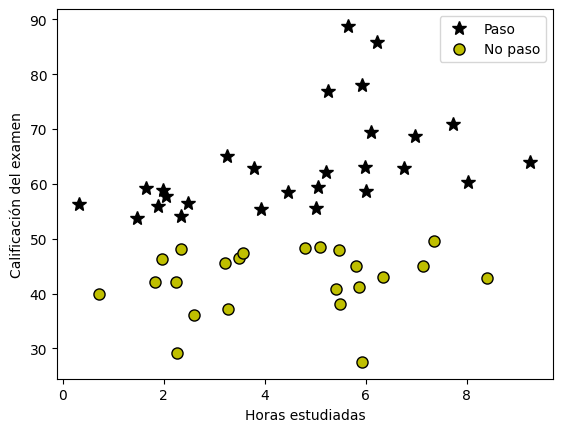

In [28]:
plotData(X[:50, [2, 18]], y[:50])
# adiciona etiquetas para los ejes
pyplot.xlabel('Horas estudiadas')
pyplot.ylabel('Calificación del examen')
pyplot.legend(['Paso', 'No paso'])
pass

In [29]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

### Sigmoide

In [30]:
# Prueba la implementacion de la funcion sigmoid
z = 0
g = sigmoid(z)

print('g(', z, ') = ', g)

g( 0 ) =  0.5


<a id="section2"></a>
### Función de Costo y Gradiente



In [31]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print(X[5])

[ 1.         19.          0.          3.49302028 87.21280776  6.08468514
 62.55579213  5.32237043  5.90847229  2.11362797  5.17876643  5.73292178
  7.98654113  8.03890604  5.29174233  0.63267379  2.          0.
  1.         46.45966599]


In [32]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [33]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

### Entrenamiento

theta calculado por el descenso por el gradiente: [-0.06604979 -0.3765393  -0.03136152 -0.2399677  -0.10153959 -0.26687475
 -0.05475046 -0.30009706 -0.16163341 -0.08639017 -0.22732781 -0.24709272
 -0.26062417 -0.28030538 -0.0363003  -0.04258376 -0.06917287 -0.05287031
 -0.03858517  0.65123807]


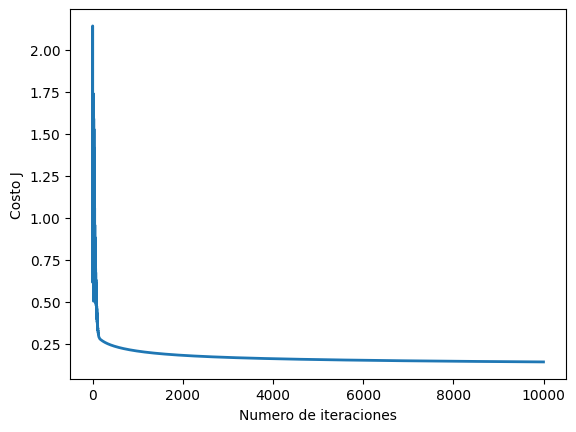

In [39]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(20)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

### Prueba

In [50]:
# Suponiendo que el 1 original estaba al final, lo movemos al principio
estudiante_raw = [21, 1, 1.5, 79.1, 8, 96.5, 7.7, 1.8, 1.55, 6.81, 7.21, 9.04, 7.76, 1.5, 4.01, 1, 1, 1, 49]
x_prueba = np.array([1] + estudiante_raw) # Insertamos el 1 del bias al inicio

# 2. ¡MUY IMPORTANTE! Si normalizaste en el entrenamiento:
# x_prueba[1:] = (x_prueba[1:] - media) / desviacion_estandar

# 3. Cálculo de la probabilidad
z = np.dot(x_prueba, theta)
probabilidad = sigmoid(z)

# 4. Resultado
print(f"--- Resultado para el Estudiante ---")
print(f"Nota Examen: {x_prueba[19]}")
print(f"Horas Estudio: {x_prueba[3]}")
print(f"Probabilidad de ingreso: {probabilidad:.10f}")

if probabilidad >= 0.5:
    print("Estado: APROBADO")
else:
    print("Estado: REPROBADO")

--- Resultado para el Estudiante ---
Nota Examen: 49.0
Horas Estudio: 1.5
Probabilidad de ingreso: 0.0528245884
Estado: REPROBADO
